# Homework: Root Finding

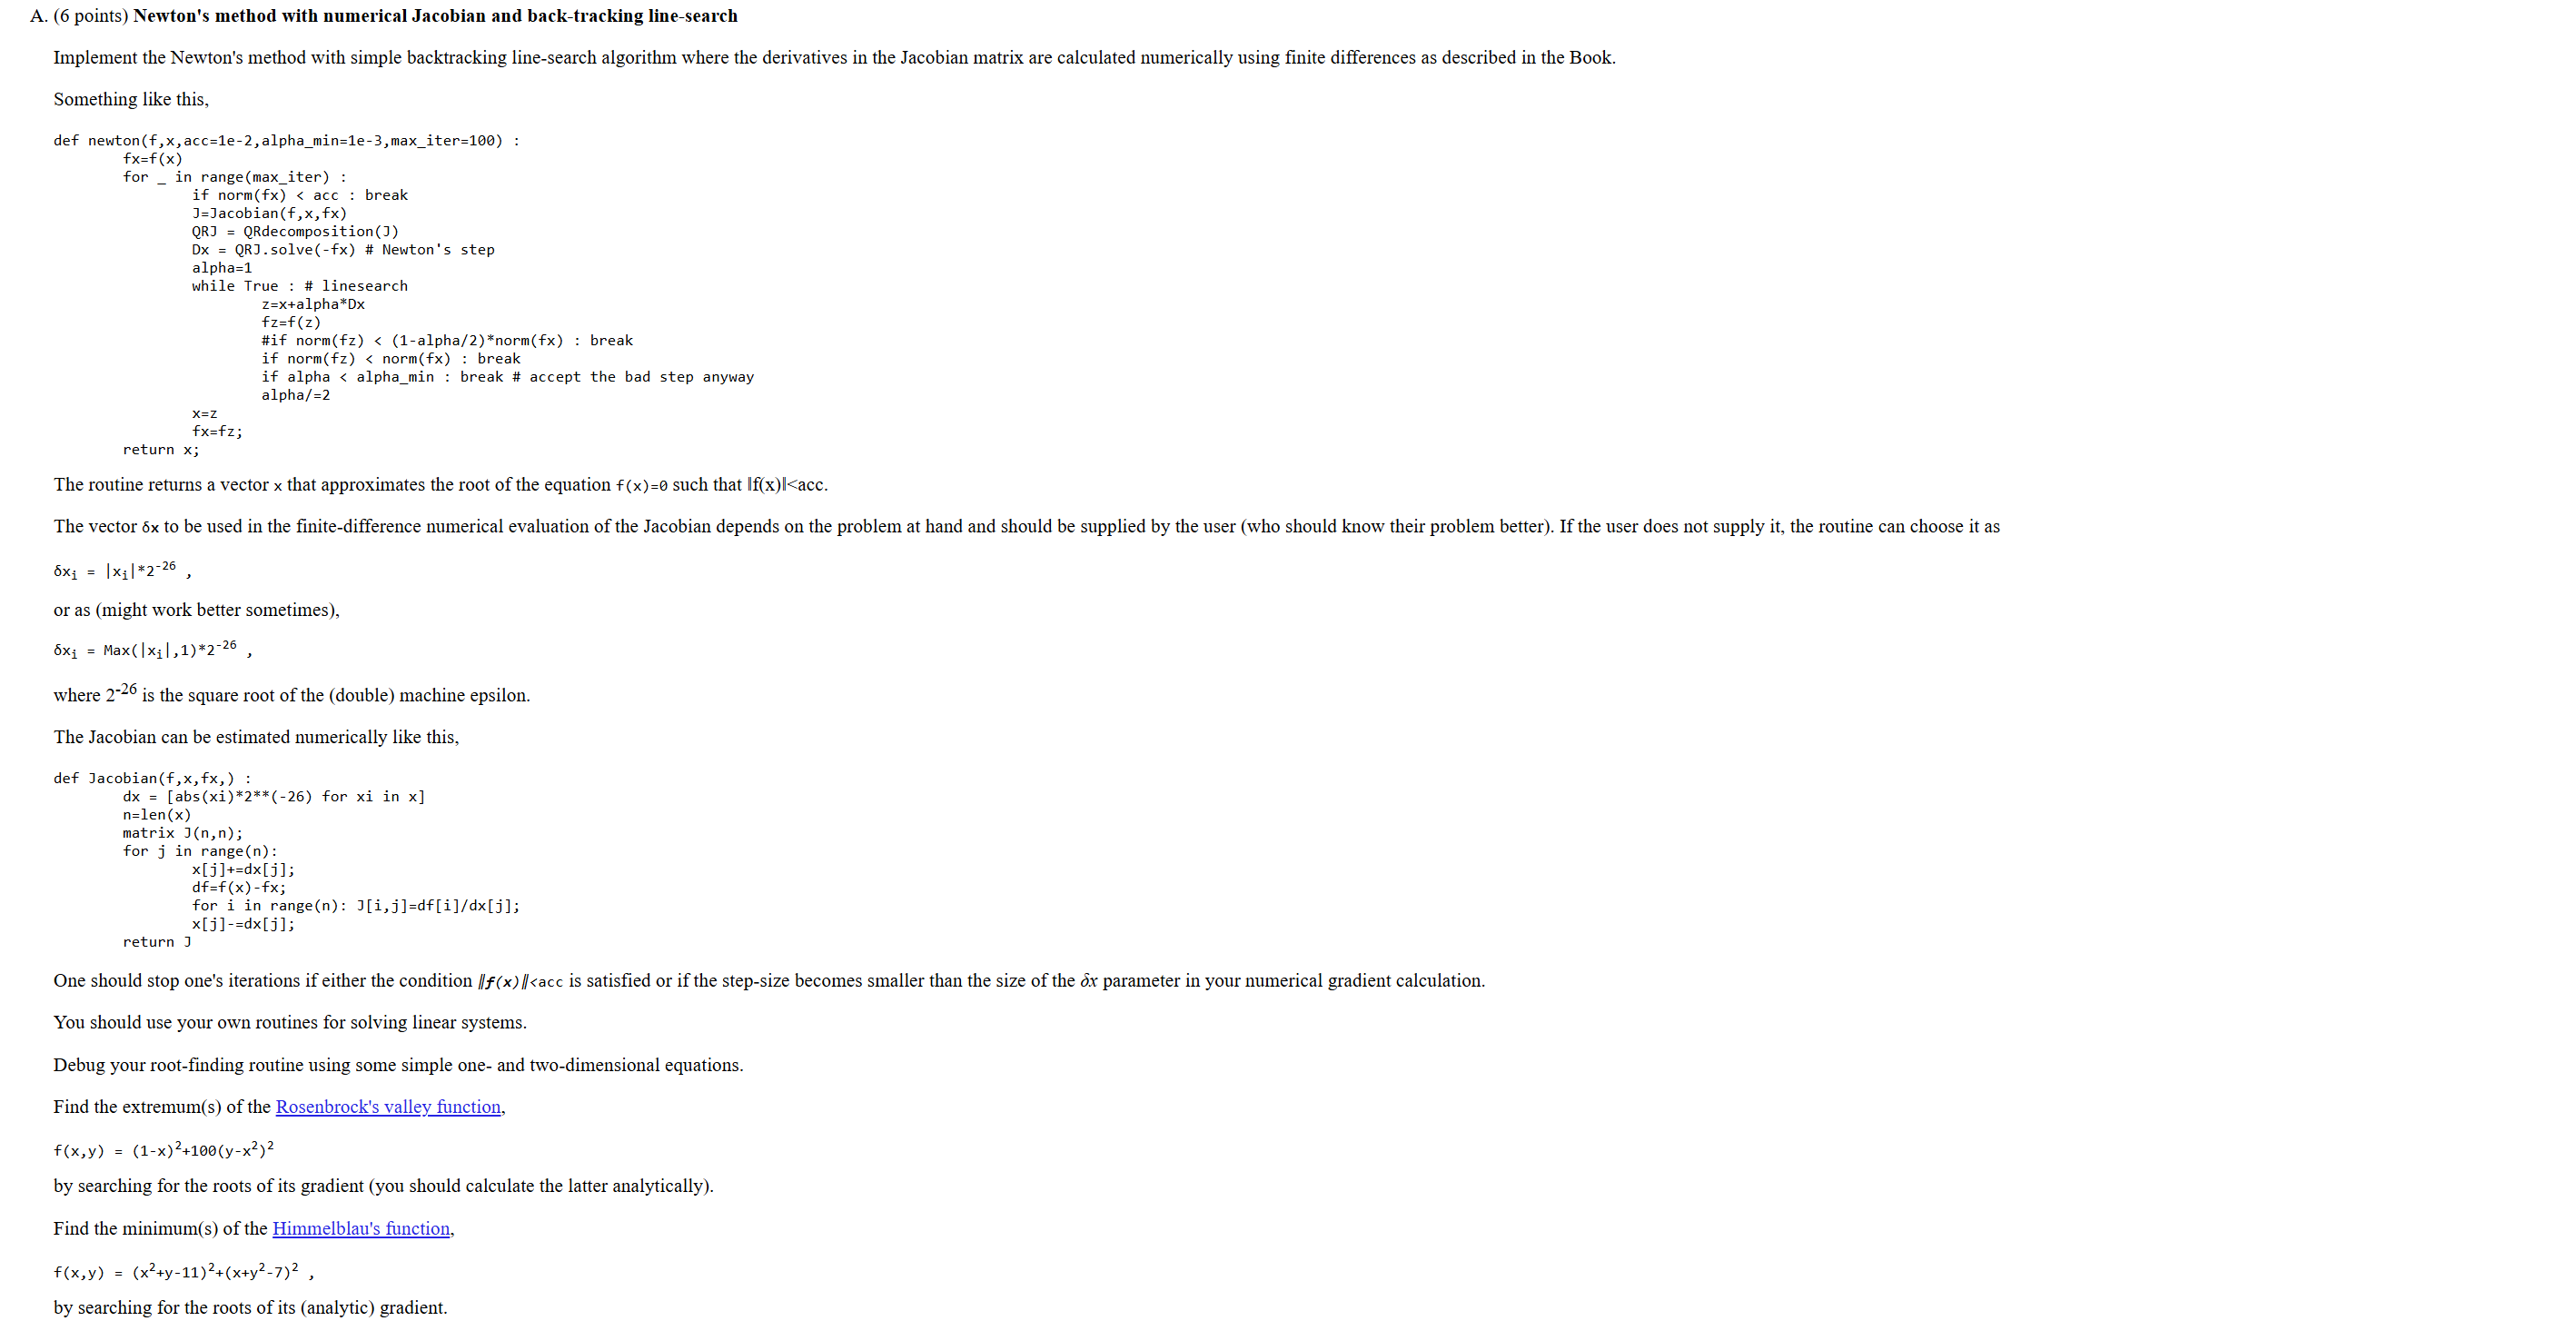

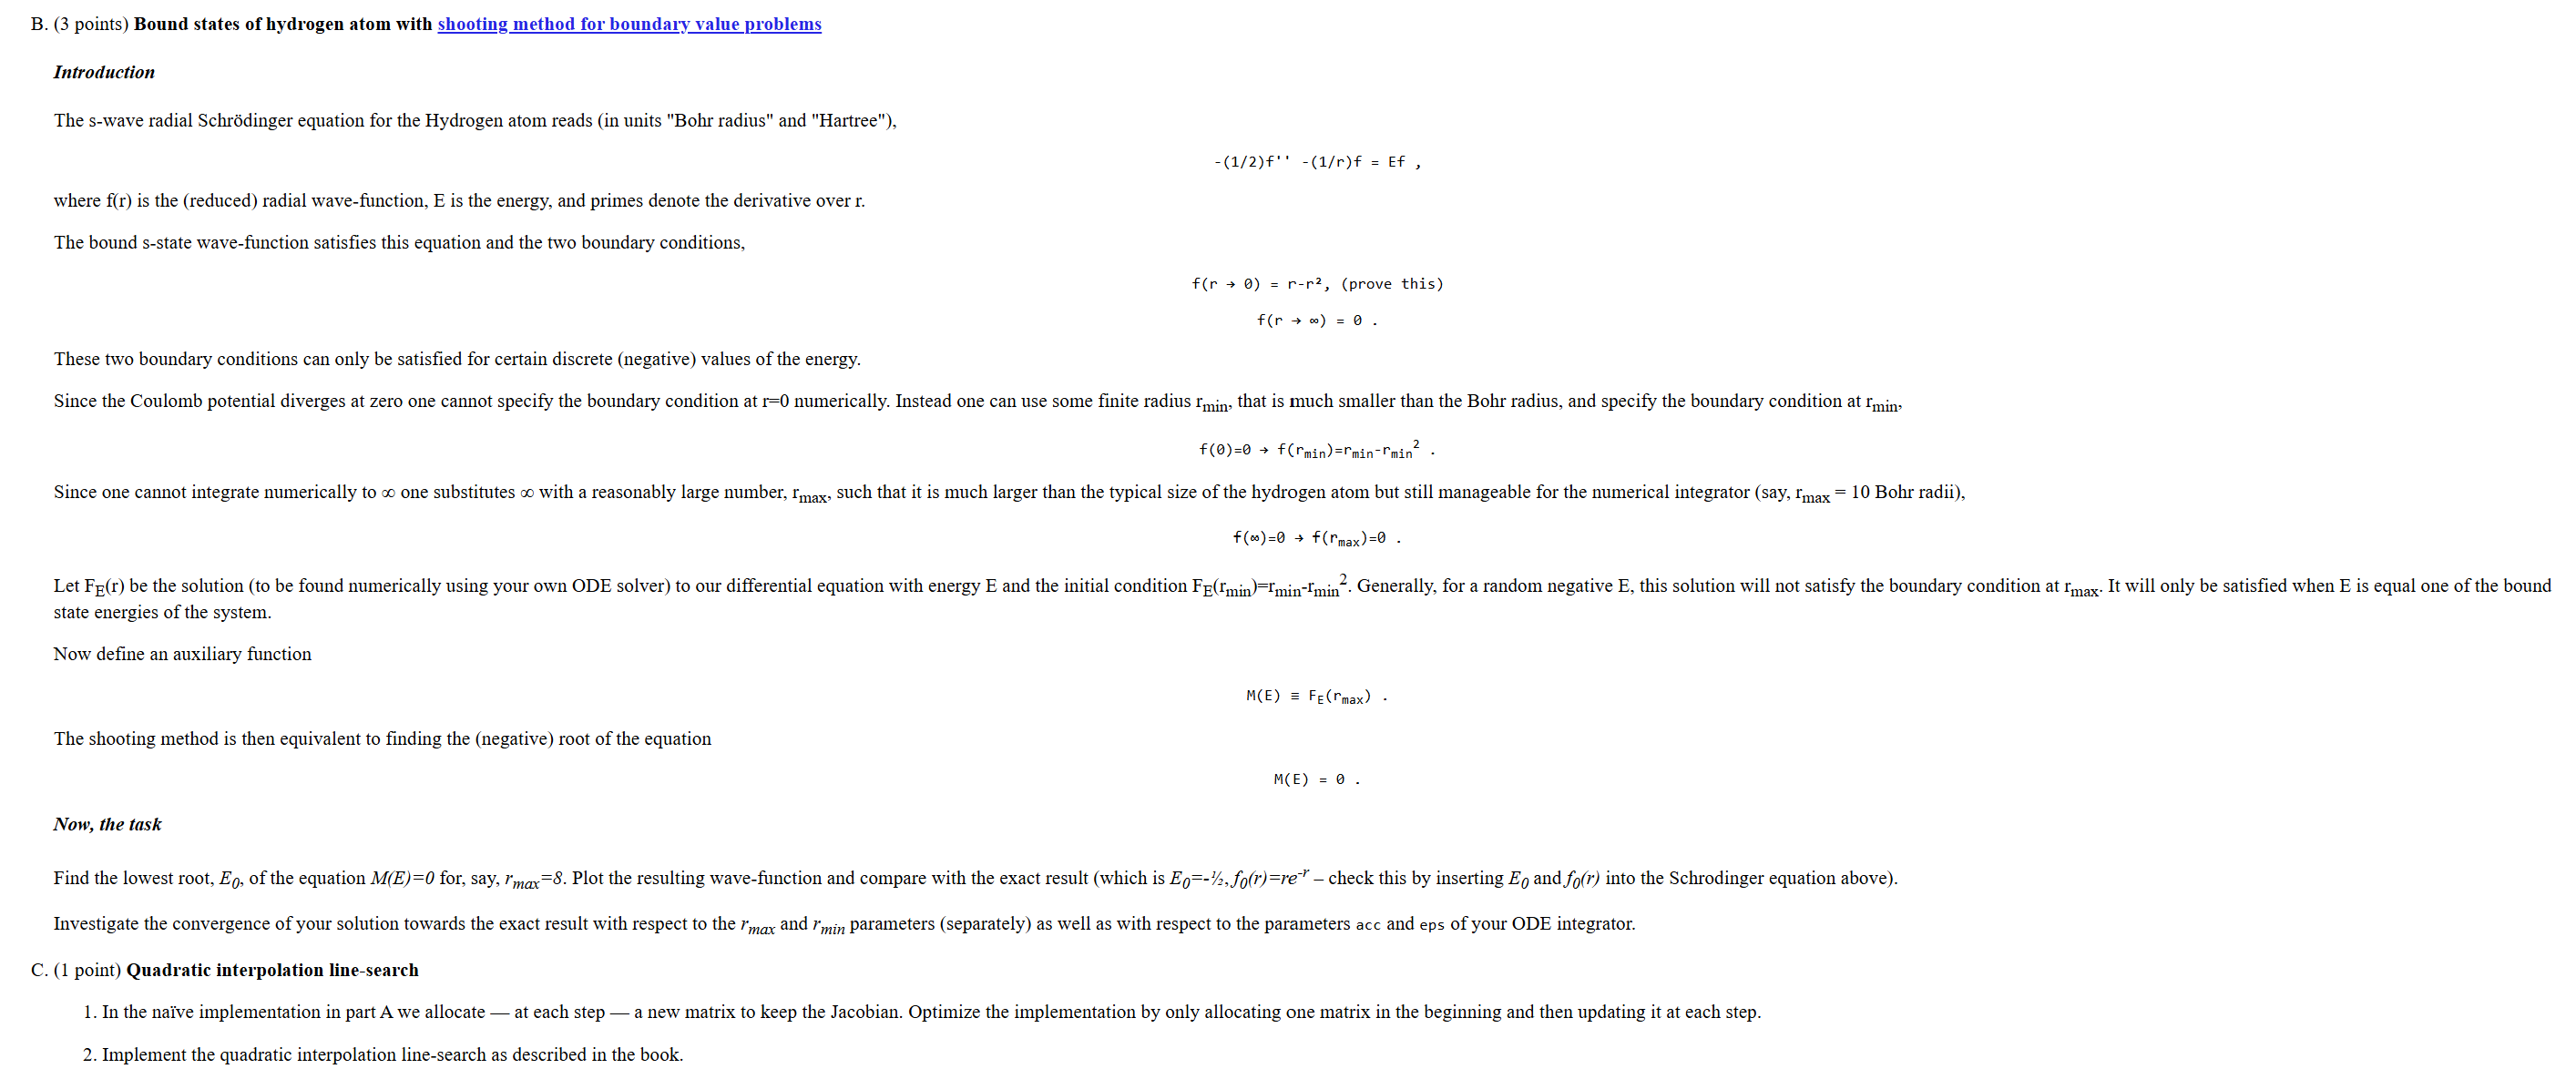

# Task A: Newton's method with numerical Jacobian and backtracking line-search

In this task, Newton's method was implemented for systems of nonlinear equations,

$$
f(x)=0.
$$

The Jacobian matrix was calculated numerically using finite differences. At each iteration, the Newton step was found by solving

$$
J \Delta x = -f(x),
$$

using an own linear-equation solver.

A backtracking line-search was included. This means that the full Newton step is first tried, and if it does not sufficiently reduce the norm of $f(x)$, the step length is reduced by factors of two.

The implementation was tested on:

- a one-dimensional nonlinear equation,
- a two-dimensional nonlinear system,
- the gradient of Rosenbrock's valley function,
- the gradient of Himmelblau's function.

Finding the roots of the gradients corresponds to finding stationary points of the corresponding functions.

In [12]:
from pathlib import Path

Path("roots.hpp").write_text(r'''
#pragma once

#include <algorithm>
#include <cmath>
#include <functional>
#include <stdexcept>
#include <vector>

namespace pp {

using vec = std::vector<double>;
using mat = std::vector<vec>;

struct newton_result {
    vec x;
    int iterations = 0;
    int backtracks = 0;
    double residual_norm = 0.0;
    bool converged = false;
    std::vector<vec> path;
};

inline double norm(const vec& v) {
    double s = 0.0;
    for (double vi : v) s += vi*vi;
    return std::sqrt(s);
}

inline vec scale(const vec& v, double a) {
    vec r(v.size());
    for (int i = 0; i < (int)v.size(); ++i) r[i] = a*v[i];
    return r;
}

inline vec axpy(const vec& x, const vec& dx, double alpha) {
    vec r(x.size());
    for (int i = 0; i < (int)x.size(); ++i) r[i] = x[i] + alpha*dx[i];
    return r;
}

inline double fd_step(double x) {
    return std::max(std::abs(x), 1.0)*std::pow(2.0, -26);
}

inline mat numerical_jacobian(
    const std::function<vec(const vec&)>& f,
    const vec& x,
    const vec& fx
) {
    int n = x.size();
    int m = fx.size();

    mat J(m, vec(n));

    for (int j = 0; j < n; ++j) {
        vec x_plus = x;
        double dx = fd_step(x[j]);

        x_plus[j] += dx;
        vec f_plus = f(x_plus);

        for (int i = 0; i < m; ++i) {
            J[i][j] = (f_plus[i] - fx[i])/dx;
        }
    }

    return J;
}

inline vec solve_linear(mat A, vec b) {
    int n = A.size();

    if ((int)b.size() != n) {
        throw std::runtime_error("solve_linear: dimension mismatch");
    }

    for (int i = 0; i < n; ++i) {
        int pivot = i;
        double best = std::abs(A[i][i]);

        for (int r = i + 1; r < n; ++r) {
            double candidate = std::abs(A[r][i]);
            if (candidate > best) {
                best = candidate;
                pivot = r;
            }
        }

        if (best < 1e-14) {
            throw std::runtime_error("solve_linear: singular matrix");
        }

        if (pivot != i) {
            std::swap(A[pivot], A[i]);
            std::swap(b[pivot], b[i]);
        }

        for (int r = i + 1; r < n; ++r) {
            double factor = A[r][i]/A[i][i];

            for (int c = i; c < n; ++c) {
                A[r][c] -= factor*A[i][c];
            }

            b[r] -= factor*b[i];
        }
    }

    vec x(n);

    for (int i = n - 1; i >= 0; --i) {
        double s = b[i];

        for (int c = i + 1; c < n; ++c) {
            s -= A[i][c]*x[c];
        }

        x[i] = s/A[i][i];
    }

    return x;
}

inline newton_result newton(
    const std::function<vec(const vec&)>& f,
    vec x,
    double acc = 1e-8,
    double alpha_min = 1.0/128.0,
    int max_iter = 100
) {
    newton_result result;
    result.path.push_back(x);

    for (int iter = 0; iter < max_iter; ++iter) {
        vec fx = f(x);
        double nfx = norm(fx);

        if (nfx < acc) {
            result.x = x;
            result.iterations = iter;
            result.residual_norm = nfx;
            result.converged = true;
            return result;
        }

        mat J = numerical_jacobian(f, x, fx);
        vec dx = solve_linear(J, scale(fx, -1.0));

        double dx_norm = norm(dx);

        double min_step = 0.0;
        for (double xi : x) {
            min_step = std::max(min_step, fd_step(xi));
        }

        if (dx_norm < min_step) {
            result.x = x;
            result.iterations = iter;
            result.residual_norm = nfx;
            result.converged = false;
            return result;
        }

        double alpha = 1.0;
        vec z;
        vec fz;
        double nfz;

        while (true) {
            z = axpy(x, dx, alpha);
            fz = f(z);
            nfz = norm(fz);

            if (nfz < (1.0 - alpha/2.0)*nfx) break;
            if (nfz < nfx) break;
            if (alpha < alpha_min) break;

            alpha /= 2.0;
            result.backtracks++;
        }

        x = z;
        result.path.push_back(x);
    }

    vec fx = f(x);

    result.x = x;
    result.iterations = max_iter;
    result.residual_norm = norm(fx);
    result.converged = result.residual_norm < acc;

    return result;
}

} // namespace pp
''')

print("Wrote roots.hpp")

Wrote roots.hpp


In [13]:
from pathlib import Path

Path("root_A.cpp").write_text(r'''
#include "roots.hpp"

#include <cmath>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <string>
#include <vector>

using pp::vec;

double rosenbrock_value(double x, double y) {
    return std::pow(1.0 - x, 2) + 100.0*std::pow(y - x*x, 2);
}

vec rosenbrock_gradient(const vec& v) {
    double x = v[0];
    double y = v[1];

    return {
        2.0*(x - 1.0) - 400.0*x*(y - x*x),
        200.0*(y - x*x)
    };
}

double himmelblau_value(double x, double y) {
    return std::pow(x*x + y - 11.0, 2) + std::pow(x + y*y - 7.0, 2);
}

vec himmelblau_gradient(const vec& v) {
    double x = v[0];
    double y = v[1];

    double A = x*x + y - 11.0;
    double B = x + y*y - 7.0;

    return {
        4.0*x*A + 2.0*B,
        2.0*A + 4.0*y*B
    };
}

void print_result(const std::string& name, const pp::newton_result& r) {
    std::cout << name << "\n";
    std::cout << "  x = ";
    for (double xi : r.x) std::cout << std::setw(16) << xi;
    std::cout << "\n";
    std::cout << "  iterations    = " << r.iterations << "\n";
    std::cout << "  backtracks    = " << r.backtracks << "\n";
    std::cout << "  residual norm = " << r.residual_norm << "\n";
    std::cout << "  converged     = " << std::boolalpha << r.converged << "\n\n";
}

void write_path_2d(const std::string& filename, const pp::newton_result& r) {
    std::ofstream out(filename);

    for (const auto& p : r.path) {
        out << p[0] << " " << p[1] << "\n";
    }
}

int main() {
    std::cout << std::setprecision(12);
    std::cout << "Task A: Newton root finding\n";
    std::cout << "===========================\n\n";

    // 1D test: cos(x)-x = 0
    auto f1 = [](const vec& x) {
        return vec{std::cos(x[0]) - x[0]};
    };

    auto r1 = pp::newton(f1, vec{1.0}, 1e-8);
    print_result("1D test: cos(x)-x = 0", r1);

    // 2D test: unit circle and x=y
    auto f2 = [](const vec& x) {
        return vec{
            x[0]*x[0] + x[1]*x[1] - 1.0,
            x[0] - x[1]
        };
    };

    auto r2 = pp::newton(f2, vec{0.8, 0.6}, 1e-8);
    print_result("2D test: x^2+y^2=1 and x=y", r2);

    // Rosenbrock minimum from root of gradient
    auto r_rosen = pp::newton(rosenbrock_gradient, vec{-1.2, 1.0}, 1e-8, 1.0/128.0, 1000);
    print_result("Rosenbrock gradient root", r_rosen);
    std::cout << "  Rosenbrock value at root = "
              << rosenbrock_value(r_rosen.x[0], r_rosen.x[1]) << "\n\n";

    write_path_2d("root_A_rosenbrock_path.data", r_rosen);

    // Himmelblau minima from roots of gradient
    std::vector<vec> starts = {
        { 2.5,  2.5},
        {-3.0,  3.0},
        {-4.0, -3.0},
        { 4.0, -2.0}
    };

    std::ofstream roots("root_A_himmelblau_roots.data");
    std::ofstream paths("root_A_himmelblau_paths.data");

    std::cout << "Himmelblau gradient roots\n";
    std::cout << "-------------------------\n";

    for (int i = 0; i < (int)starts.size(); ++i) {
        auto r = pp::newton(himmelblau_gradient, starts[i], 1e-8);

        std::cout << "start " << i+1 << ": "
                  << "(" << starts[i][0] << ", " << starts[i][1] << ")\n";

        print_result("  result", r);

        double value = himmelblau_value(r.x[0], r.x[1]);

        roots << r.x[0] << " "
              << r.x[1] << " "
              << value << " "
              << r.residual_norm << " "
              << r.iterations << "\n";

        for (const auto& p : r.path) {
            paths << p[0] << " " << p[1] << "\n";
        }
        paths << "\n\n";
    }

    std::cout << "Wrote root_A_rosenbrock_path.data\n";
    std::cout << "Wrote root_A_himmelblau_roots.data\n";
    std::cout << "Wrote root_A_himmelblau_paths.data\n";

    return 0;
}
''')

Path("Makefile").write_text(r'''
CXX = g++
CXXFLAGS = -std=c++23 -O2 -Wall -Wextra

root_A: root_A.cpp roots.hpp
	$(CXX) $(CXXFLAGS) root_A.cpp -o root_A

clean:
	rm -f root_A *.data
''')

print("Wrote root_A.cpp")
print("Wrote Makefile")

Wrote root_A.cpp
Wrote Makefile


In [14]:
import subprocess

compile_cmd = ["make", "root_A"]

r = subprocess.run(
    compile_cmd,
    text=True,
    capture_output=True
)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(
        ["./root_A"],
        text=True,
        capture_output=True
    )

    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:
g++ -std=c++23 -O2 -Wall -Wextra root_A.cpp -o root_A


Program output:
Task A: Newton root finding

1D test: cos(x)-x = 0
  x =   0.739085133385
  iterations    = 3
  backtracks    = 0
  residual norm = 2.84804735351e-10
  converged     = true

2D test: x^2+y^2=1 and x=y
  x =   0.707106782107  0.707106782107
  iterations    = 3
  backtracks    = 0
  residual norm = 2.60426014087e-09
  converged     = true

Rosenbrock gradient root
  x =                1               1
  iterations    = 155
  backtracks    = 870
  residual norm = 2.67121136327e-13
  converged     = true

  Rosenbrock value at root = 3.94584527006e-27

Himmelblau gradient roots
-------------------------
start 1: (2.5, 2.5)
  result
  x =    3.00000000159   1.99999999961
  iterations    = 4
  backtracks    = 0
  residual norm = 1.11373863627e-07
  converged     = false

start 2: (-3, 3)
  result
  x =     -2.805118096   3.13131252016
  iterations    = 3
  backtracks    = 0
  residual norm = 6.022287915

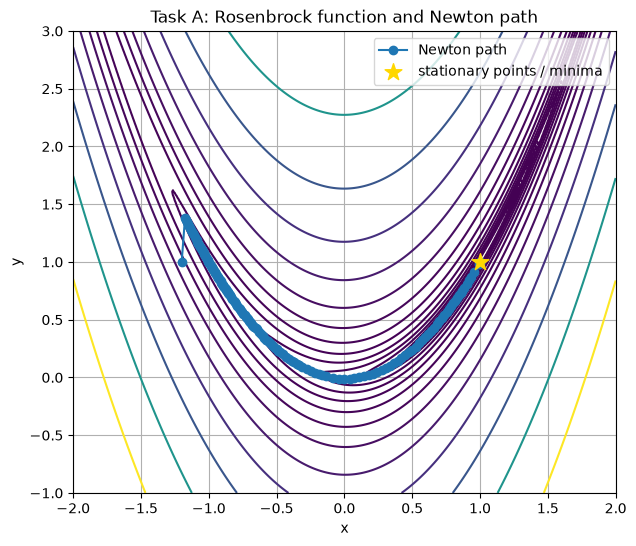

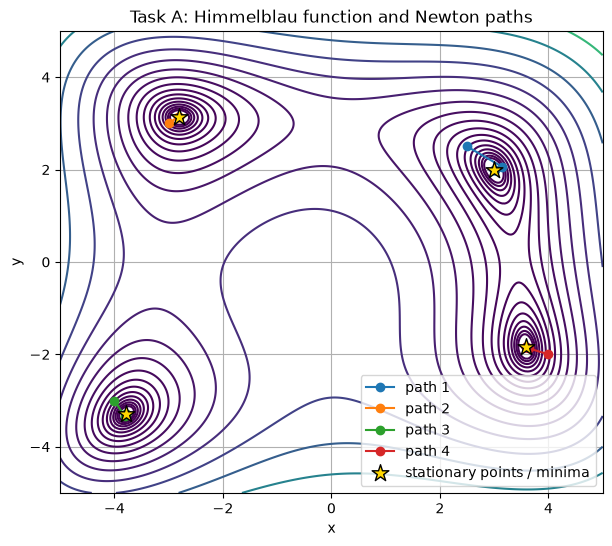

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- Rosenbrock plot ----------
rosen_path = np.loadtxt("root_A_rosenbrock_path.data")

x = np.linspace(-2.0, 2.0, 300)
y = np.linspace(-1.0, 3.0, 300)
X, Y = np.meshgrid(x, y)
Z = (1 - X)**2 + 100*(Y - X**2)**2

plt.figure(figsize=(7, 6))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 15))
plt.plot(rosen_path[:, 0], rosen_path[:, 1], marker="o", label="Newton path")
plt.scatter([1], [1], marker="*", s=160, color="gold", linewidths=1.0, label="stationary points / minima", zorder=5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Task A: Rosenbrock function and Newton path")
plt.legend()
plt.grid(True)
plt.show()


# ---------- Himmelblau plot ----------
himmel_roots = np.loadtxt("root_A_himmelblau_roots.data")

x = np.linspace(-5.0, 5.0, 400)
y = np.linspace(-5.0, 5.0, 400)
X, Y = np.meshgrid(x, y)
Z = (X**2 + Y - 11)**2 + (X + Y**2 - 7)**2

plt.figure(figsize=(7, 6))
plt.contour(X, Y, Z, levels=np.logspace(0, 3, 18))

# Read path blocks separated by blank lines
blocks = []
current = []

for line in Path("root_A_himmelblau_paths.data").read_text().splitlines():
    if line.strip():
        current.append([float(v) for v in line.split()])
    else:
        if current:
            blocks.append(np.array(current))
            current = []

if current:
    blocks.append(np.array(current))

for i, block in enumerate(blocks):
    plt.plot(block[:, 0], block[:, 1], marker="o", label=f"path {i+1}")

plt.scatter(himmel_roots[:, 0], himmel_roots[:, 1], marker="*", s=160, color="gold", edgecolors="black", linewidths=1.0, label="stationary points / minima", zorder=5)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Task A: Himmelblau function and Newton paths")
plt.legend()
plt.grid(True)
plt.show()

## Task A conclusion

Newton's method with numerical Jacobian and backtracking line-search was implemented and tested on several nonlinear systems.

The simple one-dimensional equation $\cos(x)-x=0$ converged to the expected root, and the two-dimensional test problem converged to

$$
(x,y)=\left(\frac{1}{\sqrt{2}},\frac{1}{\sqrt{2}}\right).
$$

The method was then used to find stationary points by solving gradient equations. For Rosenbrock's function, the method converged to the known minimum

$$
(x,y)=(1,1).
$$

For Himmelblau's function, different starting points converged to different minima. The contour plots show the Newton paths and confirm that the root finder works for both simple systems and more difficult nonlinear functions.

# Task B: Bound state of the hydrogen atom with the shooting method

The radial Schrödinger equation for the hydrogen atom is

$$
-\frac{1}{2}f''(r)-\frac{1}{r}f(r)=Ef(r).
$$

This is rewritten as a first-order system by defining

$$
y_0=f, \qquad y_1=f'.
$$

Then

$$
y_0'=y_1,
$$

and

$$
y_1'=-2\left(E+\frac{1}{r}\right)y_0.
$$

The integration starts at a small finite radius $r_{\min}$ because the Coulomb potential diverges at $r=0$. Near the origin the regular solution behaves as

$$
f(r)\approx r-r^2,
$$

so the initial conditions are chosen as

$$
f(r_{\min})=r_{\min}-r_{\min}^2,
$$

and

$$
f'(r_{\min})=1-2r_{\min}.
$$

For a trial energy $E$, the ODE is integrated from $r_{\min}$ to $r_{\max}$. The shooting function is

$$
M(E)=f_E(r_{\max}).
$$

The ground-state energy is found by solving

$$
M(E)=0.
$$

The exact ground-state result is

$$
E_0=-\frac{1}{2},
$$

with radial wave function proportional to

$$
f_0(r)=r e^{-r}.
$$

In [24]:
from pathlib import Path

Path("root_B.cpp").write_text(r'''
#include <algorithm>
#include <cmath>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <stdexcept>
#include <tuple>
#include <vector>

using vec = std::vector<double>;

struct ode_result {
    std::vector<double> xs;
    std::vector<vec> ys;
    int accepted = 0;
    int rejected = 0;
};

double norm(const vec& v) {
    double s = 0.0;
    for (double x : v) s += x*x;
    return std::sqrt(s);
}

vec operator+(const vec& a, const vec& b) {
    vec r(a.size());
    for (int i = 0; i < (int)a.size(); ++i) r[i] = a[i] + b[i];
    return r;
}

vec operator-(const vec& a, const vec& b) {
    vec r(a.size());
    for (int i = 0; i < (int)a.size(); ++i) r[i] = a[i] - b[i];
    return r;
}

vec operator*(double c, const vec& a) {
    vec r(a.size());
    for (int i = 0; i < (int)a.size(); ++i) r[i] = c*a[i];
    return r;
}

// Embedded Cash-Karp RK45 step.
template<class F>
std::tuple<vec, vec> rkstep45(F f, double x, const vec& y, double h) {
    vec k1 = f(x, y);

    vec k2 = f(x + h*0.2,
               y + h*(0.2*k1));

    vec k3 = f(x + h*0.3,
               y + h*((3.0/40.0)*k1 + (9.0/40.0)*k2));

    vec k4 = f(x + h*0.6,
               y + h*((3.0/10.0)*k1 - (9.0/10.0)*k2 + (6.0/5.0)*k3));

    vec k5 = f(x + h,
               y + h*((-11.0/54.0)*k1 + (5.0/2.0)*k2
                    - (70.0/27.0)*k3 + (35.0/27.0)*k4));

    vec k6 = f(x + h*0.875,
               y + h*((1631.0/55296.0)*k1 + (175.0/512.0)*k2
                    + (575.0/13824.0)*k3 + (44275.0/110592.0)*k4
                    + (253.0/4096.0)*k5));

    vec y5 = y + h*((37.0/378.0)*k1
                  + (250.0/621.0)*k3
                  + (125.0/594.0)*k4
                  + (512.0/1771.0)*k6);

    vec y4 = y + h*((2825.0/27648.0)*k1
                  + (18575.0/48384.0)*k3
                  + (13525.0/55296.0)*k4
                  + (277.0/14336.0)*k5
                  + (1.0/4.0)*k6);

    vec err = y5 - y4;

    return {y5, err};
}

template<class F>
ode_result driver(
    F f,
    double a,
    double b,
    vec y,
    double h = 0.05,
    double acc = 1e-8,
    double eps = 1e-8,
    bool save = false
) {
    ode_result result;
    double x = a;

    if (save) {
        result.xs.push_back(x);
        result.ys.push_back(y);
    }

    while (x < b) {
        if (x + h > b) h = b - x;

        auto [yh, err_vec] = rkstep45(f, x, y, h);

        double err = norm(err_vec);
        double tol = (acc + eps*norm(yh))*std::sqrt(h/(b-a));

        if (err <= tol || h < 1e-12) {
            x += h;
            y = yh;
            result.accepted++;

            if (save) {
                result.xs.push_back(x);
                result.ys.push_back(y);
            }
        } else {
            result.rejected++;
        }

        if (err > 0.0) {
            double factor = 0.95*std::pow(tol/err, 0.2);
            factor = std::clamp(factor, 0.1, 2.0);
            h *= factor;
        } else {
            h *= 2.0;
        }
    }

    if (!save) {
        result.xs.push_back(x);
        result.ys.push_back(y);
    }

    return result;
}

ode_result integrate_hydrogen(
    double E,
    double rmin,
    double rmax,
    double acc,
    double eps,
    bool save
) {
    auto schrodinger = [E](double r, const vec& y) {
        return vec{
            y[1],
            -2.0*(E + 1.0/r)*y[0]
        };
    };

    vec y0 = {
        rmin - rmin*rmin,
        1.0 - 2.0*rmin
    };

    return driver(schrodinger, rmin, rmax, y0, 0.05, acc, eps, save);
}

double shoot_endpoint(
    double E,
    double rmin,
    double rmax,
    double acc,
    double eps
) {
    ode_result sol = integrate_hydrogen(E, rmin, rmax, acc, eps, false);
    return sol.ys.back()[0];
}

// Robust scalar root finder for M(E)=0.
double find_ground_energy(
    double rmin,
    double rmax,
    double acc,
    double eps
) {
    double a = -0.7;
    double b = -0.2;

    double fa = shoot_endpoint(a, rmin, rmax, acc, eps);
    double fb = shoot_endpoint(b, rmin, rmax, acc, eps);

    if (fa*fb > 0.0) {
        throw std::runtime_error("Could not bracket the ground-state energy.");
    }

    for (int iter = 0; iter < 100; ++iter) {
        double c = 0.5*(a+b);
        double fc = shoot_endpoint(c, rmin, rmax, acc, eps);

        if (std::abs(fc) < acc || std::abs(b-a) < 1e-10) {
            return c;
        }

        if (fa*fc < 0.0) {
            b = c;
            fb = fc;
        } else {
            a = c;
            fa = fc;
        }
    }

    return 0.5*(a+b);
}

double exact_wavefunction(double r) {
    return r*std::exp(-r);
}

void write_wavefunction(
    const std::string& filename,
    double E,
    double rmin,
    double rmax,
    double acc,
    double eps
) {
    ode_result sol = integrate_hydrogen(E, rmin, rmax, acc, eps, true);

    std::ofstream out(filename);

    for (int i = 0; i < (int)sol.xs.size(); ++i) {
        double r = sol.xs[i];
        double fnum = sol.ys[i][0];
        double fexact = exact_wavefunction(r);

        out << r << " "
            << fnum << " "
            << fexact << " "
            << std::abs(fnum - fexact) << "\n";
    }
}

int main() {
    std::cout << std::setprecision(12);

    std::cout << "Task B: hydrogen bound state by shooting\n";
    std::cout << "========================================\n\n";

    const double exact_E0 = -0.5;

    double rmin = 1e-4;
    double rmax = 12.0;
    double acc = 1e-8;
    double eps = 1e-8;

    double E0 = find_ground_energy(rmin, rmax, acc, eps);
    ode_result sol = integrate_hydrogen(E0, rmin, rmax, acc, eps, true);

    std::cout << "Main calculation\n";
    std::cout << "----------------\n";
    std::cout << "rmin             = " << rmin << "\n";
    std::cout << "rmax             = " << rmax << "\n";
    std::cout << "acc              = " << acc << "\n";
    std::cout << "eps              = " << eps << "\n";
    std::cout << "computed E0      = " << E0 << "\n";
    std::cout << "exact E0         = " << exact_E0 << "\n";
    std::cout << "absolute error   = " << std::abs(E0 - exact_E0) << "\n";
    std::cout << "M(E0)=f(rmax)    = " << sol.ys.back()[0] << "\n";
    std::cout << "accepted steps   = " << sol.accepted << "\n";
    std::cout << "rejected steps   = " << sol.rejected << "\n\n";

    write_wavefunction("root_B_wavefunction.data", E0, rmin, rmax, acc, eps);

    std::ofstream conv_rmax("root_B_convergence_rmax.data");
    for (double R : {4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0}) {
        double E = find_ground_energy(rmin, R, acc, eps);
        conv_rmax << R << " " << E << " " << std::abs(E - exact_E0) << "\n";
    }

    std::ofstream conv_rmin("root_B_convergence_rmin.data");
    for (double r0 : {1e-1, 5e-2, 1e-2, 5e-3, 1e-3, 5e-4, 1e-4}) {
        double E = find_ground_energy(r0, rmax, acc, eps);
        conv_rmin << r0 << " " << E << " " << std::abs(E - exact_E0) << "\n";
    }

    std::ofstream conv_acc("root_B_convergence_acc.data");
    for (double a : {1e-4, 1e-5, 1e-6, 1e-7, 1e-8}) {
        double E = find_ground_energy(rmin, rmax, a, a);
        conv_acc << a << " " << E << " " << std::abs(E - exact_E0) << "\n";
    }

    std::cout << "Wrote root_B_wavefunction.data\n";
    std::cout << "Wrote root_B_convergence_rmax.data\n";
    std::cout << "Wrote root_B_convergence_rmin.data\n";
    std::cout << "Wrote root_B_convergence_acc.data\n";

    return 0;
}
''')

print("Wrote root_B.cpp")

Wrote root_B.cpp


In [25]:
from pathlib import Path

Path("Makefile").write_text(r'''
CXX = g++
CXXFLAGS = -std=c++23 -O2 -Wall -Wextra

all: root_A root_B

root_A: root_A.cpp roots.hpp
	$(CXX) $(CXXFLAGS) root_A.cpp -o root_A

root_B: root_B.cpp
	$(CXX) $(CXXFLAGS) root_B.cpp -o root_B

clean:
	rm -f root_A root_B *.data
''')

print("Wrote Makefile")

Wrote Makefile


In [26]:
import subprocess

r = subprocess.run(
    ["make", "root_B"],
    text=True,
    capture_output=True
)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(
        ["./root_B"],
        text=True,
        capture_output=True
    )

    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:
g++ -std=c++23 -O2 -Wall -Wextra root_B.cpp -o root_B


Program output:
Task B: hydrogen bound state by shooting

Main calculation
----------------
rmin             = 0.0001
rmax             = 12
acc              = 1e-08
eps              = 1e-08
computed E0      = -0.499999979994
exact E0         = -0.5
absolute error   = 2.00059731004e-08
M(E0)=f(rmax)    = -6.18380195588e-08
accepted steps   = 95
rejected steps   = 5

Wrote root_B_wavefunction.data
Wrote root_B_convergence_rmax.data
Wrote root_B_convergence_rmin.data
Wrote root_B_convergence_acc.data




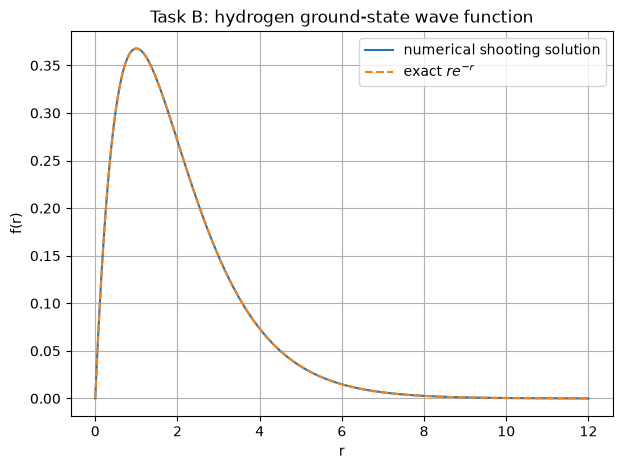

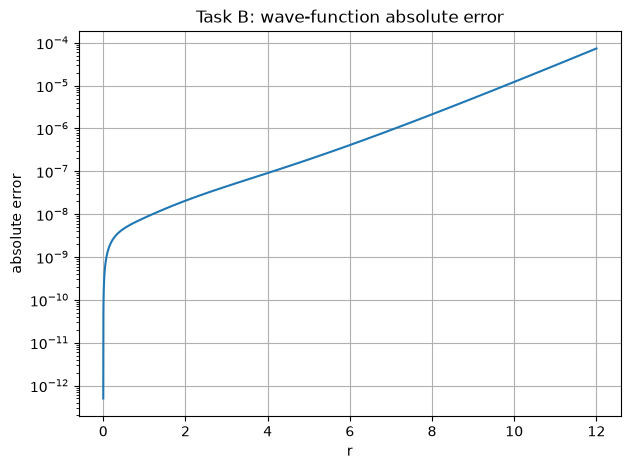

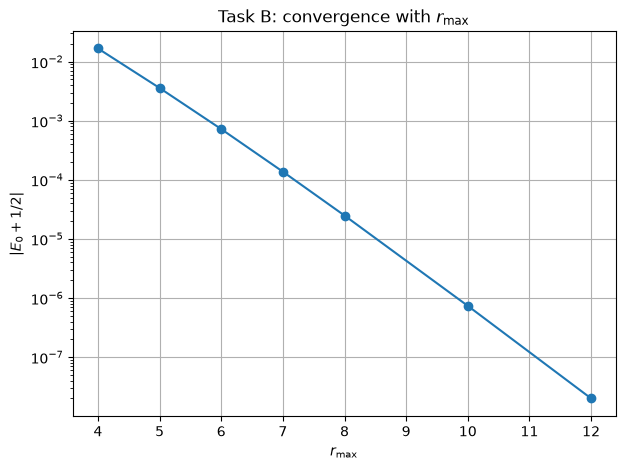

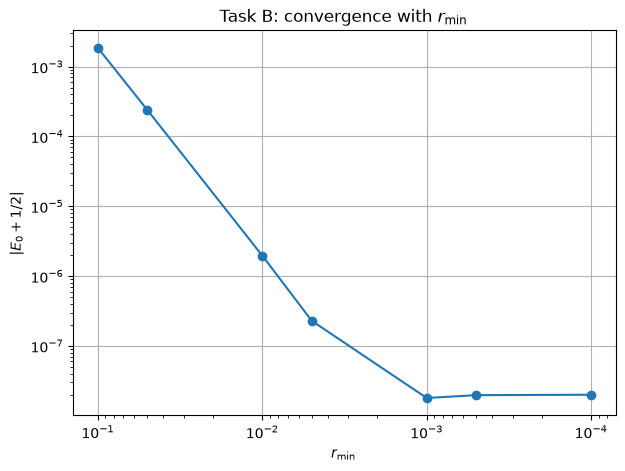

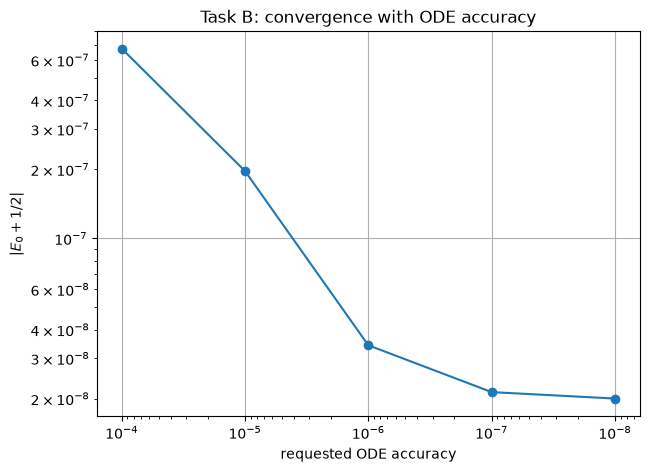

In [27]:
import numpy as np
import matplotlib.pyplot as plt

wave = np.loadtxt("root_B_wavefunction.data")

r = wave[:, 0]
fnum = wave[:, 1]
fexact = wave[:, 2]
err = wave[:, 3]

plt.figure(figsize=(7, 5))
plt.plot(r, fnum, label="numerical shooting solution")
plt.plot(r, fexact, "--", label=r"exact $r e^{-r}$")
plt.xlabel("r")
plt.ylabel("f(r)")
plt.title("Task B: hydrogen ground-state wave function")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.semilogy(r, err)
plt.xlabel("r")
plt.ylabel("absolute error")
plt.title("Task B: wave-function absolute error")
plt.grid(True)
plt.show()

conv_rmax = np.loadtxt("root_B_convergence_rmax.data")

plt.figure(figsize=(7, 5))
plt.semilogy(conv_rmax[:, 0], conv_rmax[:, 2], marker="o")
plt.xlabel(r"$r_{\max}$")
plt.ylabel(r"$|E_0+1/2|$")
plt.title(r"Task B: convergence with $r_{\max}$")
plt.grid(True)
plt.show()

conv_rmin = np.loadtxt("root_B_convergence_rmin.data")

plt.figure(figsize=(7, 5))
plt.loglog(conv_rmin[:, 0], conv_rmin[:, 2], marker="o")
plt.gca().invert_xaxis()
plt.xlabel(r"$r_{\min}$")
plt.ylabel(r"$|E_0+1/2|$")
plt.title(r"Task B: convergence with $r_{\min}$")
plt.grid(True)
plt.show()

conv_acc = np.loadtxt("root_B_convergence_acc.data")

plt.figure(figsize=(7, 5))
plt.loglog(conv_acc[:, 0], conv_acc[:, 2], marker="o")
plt.gca().invert_xaxis()
plt.xlabel("requested ODE accuracy")
plt.ylabel(r"$|E_0+1/2|$")
plt.title("Task B: convergence with ODE accuracy")
plt.grid(True)
plt.show()

## Task B conclusion

The hydrogen ground-state energy was found using the shooting method. The radial Schrödinger equation was rewritten as a first-order ODE system and integrated from a small finite radius $r_{\min}$ to a finite cutoff radius $r_{\max}$.

Using

$$
r_{\min}=10^{-4}
$$

and

$$
r_{\max}=12,
$$

the computed ground-state energy was

$$
E_0 \approx -0.49999998.
$$

This agrees very well with the exact value

$$
E_0=-\frac{1}{2},
$$

with an absolute error of about

$$
2.0\cdot 10^{-8}.
$$

The numerical wave function agrees closely with the exact result

$$
f(r)=re^{-r}.
$$

The convergence plots show that increasing $r_{\max}$ improves the energy significantly. Decreasing $r_{\min}$ also improves the result until the error reaches a plateau. The convergence with respect to the ODE accuracy also saturates, showing that the remaining error is mainly due to the finite boundary parameters rather than the ODE integrator itself.

# Task C: Quadratic interpolation line-search

In Task C, Newton's method from Task A is improved in two ways.

First, the Jacobian matrix is allocated only once at the beginning of the Newton routine and then updated in-place during each iteration. This avoids repeatedly allocating a new matrix.

Second, the simple backtracking line-search is replaced by a quadratic interpolation line-search. If the full Newton step is not accepted, a quadratic model of the merit function

$$
g(\alpha)=||f(x+\alpha \Delta x)||^2
$$

is used to choose a better reduced step length $\alpha$.

The method is tested on the same problems as in Task A: a simple one-dimensional equation, Rosenbrock's function by solving $\nabla f=0$, and Himmelblau's function by solving $\nabla f=0$ from several different starting points.

In [28]:
from pathlib import Path

Path("root_C.cpp").write_text(r'''
#include <algorithm>
#include <cmath>
#include <fstream>
#include <functional>
#include <iomanip>
#include <iostream>
#include <stdexcept>
#include <string>
#include <vector>

using vec = std::vector<double>;
using matrix = std::vector<vec>;
using function = std::function<vec(const vec&)>;

double norm(const vec& v) {
    double s = 0.0;
    for (double x : v) s += x*x;
    return std::sqrt(s);
}

vec operator+(const vec& a, const vec& b) {
    vec r(a.size());
    for (size_t i = 0; i < a.size(); ++i) r[i] = a[i] + b[i];
    return r;
}

vec operator-(const vec& a, const vec& b) {
    vec r(a.size());
    for (size_t i = 0; i < a.size(); ++i) r[i] = a[i] - b[i];
    return r;
}

vec operator*(double c, const vec& a) {
    vec r(a.size());
    for (size_t i = 0; i < a.size(); ++i) r[i] = c*a[i];
    return r;
}

std::ostream& operator<<(std::ostream& os, const vec& v) {
    for (double x : v) os << std::setw(18) << x;
    return os;
}

// Gaussian elimination with partial pivoting.
// The matrix A is modified in-place, so no new matrix is allocated inside the solver.
vec solve_linear_inplace(matrix& A, vec b) {
    const int n = (int)b.size();

    for (int k = 0; k < n; ++k) {
        int pivot = k;

        for (int i = k + 1; i < n; ++i) {
            if (std::abs(A[i][k]) > std::abs(A[pivot][k])) {
                pivot = i;
            }
        }

        if (std::abs(A[pivot][k]) < 1e-14) {
            throw std::runtime_error("singular matrix in solve_linear_inplace");
        }

        std::swap(A[k], A[pivot]);
        std::swap(b[k], b[pivot]);

        for (int i = k + 1; i < n; ++i) {
            double factor = A[i][k]/A[k][k];

            for (int j = k; j < n; ++j) {
                A[i][j] -= factor*A[k][j];
            }

            b[i] -= factor*b[k];
        }
    }

    vec x(n);

    for (int i = n - 1; i >= 0; --i) {
        double s = b[i];

        for (int j = i + 1; j < n; ++j) {
            s -= A[i][j]*x[j];
        }

        x[i] = s/A[i][i];
    }

    return x;
}

// Numerical Jacobian.
// The matrix J is allocated once in Newton's method and only updated here.
void jacobian_inplace(
    const function& f,
    const vec& x,
    const vec& fx,
    matrix& J,
    vec& x_step
) {
    const int n = (int)x.size();

    for (int j = 0; j < n; ++j) {
        x_step = x;

        double dx = std::max(std::abs(x[j]), 1.0)*std::pow(2.0, -26);

        x_step[j] += dx;
        vec df = f(x_step);

        for (int i = 0; i < n; ++i) {
            J[i][j] = (df[i] - fx[i])/dx;
        }
    }
}

struct root_result {
    vec x;
    std::vector<vec> path;
    int iterations = 0;
    int line_search_steps = 0;
    bool converged = false;
    double residual_norm = NAN;
};

// Newton method with quadratic interpolation line-search.
root_result newton_quadratic(
    const function& f,
    vec x,
    double acc = 1e-8,
    double alpha_min = 1e-4,
    int max_iter = 200
) {
    const int n = (int)x.size();

    // Allocated once and reused during all Newton iterations.
    matrix J(n, vec(n));
    vec x_step(n);

    root_result result;
    result.path.push_back(x);

    vec fx = f(x);
    double fx_norm = norm(fx);

    for (int iter = 0; iter < max_iter; ++iter) {
        if (fx_norm < acc) {
            result.converged = true;
            break;
        }

        jacobian_inplace(f, x, fx, J, x_step);

        vec minus_fx = (-1.0)*fx;
        vec dx = solve_linear_inplace(J, minus_fx);

        double alpha = 1.0;
        vec z;
        vec fz;
        double fz_norm = NAN;

        double g0 = fx_norm*fx_norm;

        // For an exact Newton step, the local derivative of g(alpha)=||f(x+alpha*dx)||^2
        // is approximately -2*g0 at alpha=0.
        double slope0 = -2.0*g0;

        while (true) {
            z = x + alpha*dx;
            fz = f(z);
            fz_norm = norm(fz);

            bool armijo = fz_norm < (1.0 - alpha/2.0)*fx_norm;
            bool improvement = fz_norm < fx_norm;

            if (armijo || improvement || alpha < alpha_min) {
                break;
            }

            double g_alpha = fz_norm*fz_norm;

            // Fit q(alpha)=g0+slope0*alpha+c*alpha^2 through the trial point.
            double c = (g_alpha - g0 - slope0*alpha)/(alpha*alpha);

            double alpha_new = 0.5*alpha;

            if (c > 0.0 && std::isfinite(c)) {
                alpha_new = -slope0/(2.0*c);
            }

            // Keep the interpolation conservative.
            alpha_new = std::clamp(alpha_new, 0.1*alpha, 0.5*alpha);

            alpha = alpha_new;
            result.line_search_steps++;
        }

        x = z;
        fx = fz;
        fx_norm = fz_norm;

        result.iterations = iter + 1;
        result.path.push_back(x);

        if (norm(alpha*dx) < 1e-12) {
            break;
        }
    }

    result.x = x;
    result.residual_norm = fx_norm;

    if (fx_norm < acc) {
        result.converged = true;
    }

    return result;
}

// Ordinary backtracking method, included for comparison.
root_result newton_backtracking(
    const function& f,
    vec x,
    double acc = 1e-8,
    double alpha_min = 1e-4,
    int max_iter = 200
) {
    const int n = (int)x.size();

    matrix J(n, vec(n));
    vec x_step(n);

    root_result result;
    result.path.push_back(x);

    vec fx = f(x);
    double fx_norm = norm(fx);

    for (int iter = 0; iter < max_iter; ++iter) {
        if (fx_norm < acc) {
            result.converged = true;
            break;
        }

        jacobian_inplace(f, x, fx, J, x_step);

        vec minus_fx = (-1.0)*fx;
        vec dx = solve_linear_inplace(J, minus_fx);

        double alpha = 1.0;
        vec z;
        vec fz;
        double fz_norm = NAN;

        while (true) {
            z = x + alpha*dx;
            fz = f(z);
            fz_norm = norm(fz);

            if (fz_norm < (1.0 - alpha/2.0)*fx_norm) break;
            if (fz_norm < fx_norm) break;
            if (alpha < alpha_min) break;

            alpha /= 2.0;
            result.line_search_steps++;
        }

        x = z;
        fx = fz;
        fx_norm = fz_norm;

        result.iterations = iter + 1;
        result.path.push_back(x);

        if (norm(alpha*dx) < 1e-12) {
            break;
        }
    }

    result.x = x;
    result.residual_norm = fx_norm;

    if (fx_norm < acc) {
        result.converged = true;
    }

    return result;
}

void write_path(const std::string& filename, const std::vector<vec>& path) {
    std::ofstream out(filename);

    for (const auto& p : path) {
        out << p << "\n";
    }
}

void append_path_block(std::ofstream& out, const std::vector<vec>& path) {
    for (const auto& p : path) {
        out << p << "\n";
    }

    out << "\n";
}

vec rosenbrock_gradient(const vec& p) {
    double x = p[0];
    double y = p[1];

    return vec{
        -2.0*(1.0 - x) - 400.0*x*(y - x*x),
        200.0*(y - x*x)
    };
}

double rosenbrock_function(double x, double y) {
    return std::pow(1.0 - x, 2) + 100.0*std::pow(y - x*x, 2);
}

vec himmelblau_gradient(const vec& p) {
    double x = p[0];
    double y = p[1];

    double A = x*x + y - 11.0;
    double B = x + y*y - 7.0;

    return vec{
        4.0*x*A + 2.0*B,
        2.0*A + 4.0*y*B
    };
}

double himmelblau_function(double x, double y) {
    return std::pow(x*x + y - 11.0, 2) + std::pow(x + y*y - 7.0, 2);
}

void print_result(const std::string& name, const root_result& r) {
    std::cout << name << "\n";
    std::cout << "  x                 = " << r.x << "\n";
    std::cout << "  iterations        = " << r.iterations << "\n";
    std::cout << "  line-search steps = " << r.line_search_steps << "\n";
    std::cout << "  residual norm     = " << r.residual_norm << "\n";
    std::cout << "  converged         = " << std::boolalpha << r.converged << "\n\n";
}

int main() {
    std::cout << std::setprecision(12);

    std::cout << "Task C: quadratic interpolation line-search\n";
    std::cout << "===========================================\n\n";

    function f1d = [](const vec& x) {
        return vec{std::cos(x[0]) - x[0]};
    };

    auto simple = newton_quadratic(f1d, vec{1.0}, 1e-8);
    print_result("1D test: cos(x)-x=0", simple);

    auto rosen_back = newton_backtracking(
        rosenbrock_gradient,
        vec{-1.2, 1.0},
        1e-8,
        1e-4,
        300
    );

    auto rosen_quad = newton_quadratic(
        rosenbrock_gradient,
        vec{-1.2, 1.0},
        1e-8,
        1e-4,
        300
    );

    print_result("Rosenbrock gradient root, ordinary backtracking", rosen_back);
    print_result("Rosenbrock gradient root, quadratic interpolation", rosen_quad);

    write_path("root_C_rosenbrock_path.data", rosen_quad.path);

    std::ofstream himmel_paths("root_C_himmelblau_paths.data");
    std::ofstream himmel_roots("root_C_himmelblau_roots.data");

    std::vector<vec> starts = {
        {2.6, 2.5},
        {-3.0, 3.0},
        {-4.0, -3.0},
        {4.0, -2.0}
    };

    int count = 1;

    for (const auto& start : starts) {
        auto r = newton_quadratic(
            himmelblau_gradient,
            start,
            1e-8,
            1e-4,
            200
        );

        print_result("Himmelblau path " + std::to_string(count), r);

        append_path_block(himmel_paths, r.path);
        himmel_roots << r.x << "\n";

        count++;
    }

    std::ofstream summary("root_C_summary.data");

    summary << "method iterations line_search_steps residual\n";

    summary << "backtracking "
            << rosen_back.iterations << " "
            << rosen_back.line_search_steps << " "
            << rosen_back.residual_norm << "\n";

    summary << "quadratic "
            << rosen_quad.iterations << " "
            << rosen_quad.line_search_steps << " "
            << rosen_quad.residual_norm << "\n";

    std::cout << "Wrote root_C_rosenbrock_path.data\n";
    std::cout << "Wrote root_C_himmelblau_paths.data\n";
    std::cout << "Wrote root_C_himmelblau_roots.data\n";
    std::cout << "Wrote root_C_summary.data\n";

    return 0;
}
''')

print("Wrote root_C.cpp")

Wrote root_C.cpp


In [29]:
from pathlib import Path

Path("Makefile").write_text(r'''
CXX = g++
CXXFLAGS = -std=c++23 -O2 -Wall -Wextra

all: root_A root_B root_C

root_A: root_A.cpp roots.hpp
	$(CXX) $(CXXFLAGS) root_A.cpp -o root_A

root_B: root_B.cpp
	$(CXX) $(CXXFLAGS) root_B.cpp -o root_B

root_C: root_C.cpp
	$(CXX) $(CXXFLAGS) root_C.cpp -o root_C

clean:
	rm -f root_A root_B root_C *.data
''')

print("Wrote Makefile")

Wrote Makefile


In [30]:
import subprocess

r = subprocess.run(
    ["make", "root_C"],
    text=True,
    capture_output=True
)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(
        ["./root_C"],
        text=True,
        capture_output=True
    )

    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:
g++ -std=c++23 -O2 -Wall -Wextra root_C.cpp -o root_C


Program output:
Task C: quadratic interpolation line-search

1D test: cos(x)-x=0
  x                 =     0.739085133385
  iterations        = 3
  line-search steps = 0
  residual norm     = 2.84804735351e-10
  converged         = true

Rosenbrock gradient root, ordinary backtracking
  x                 =                  1                 1
  iterations        = 180
  line-search steps = 1121
  residual norm     = 2.18609200399e-13
  converged         = true

Rosenbrock gradient root, quadratic interpolation
  x                 =     0.999999999999    0.999999999998
  iterations        = 252
  line-search steps = 573
  residual norm     = 1.98885024163e-12
  converged         = true

Himmelblau path 1
  x                 =                  3                 2
  iterations        = 5
  line-search steps = 0
  residual norm     = 0
  converged         = true

Himmelblau path 2
  x                 =     -2.80511808

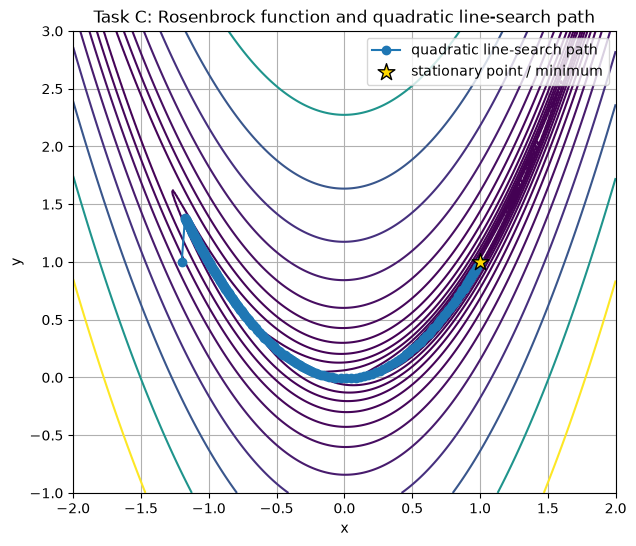

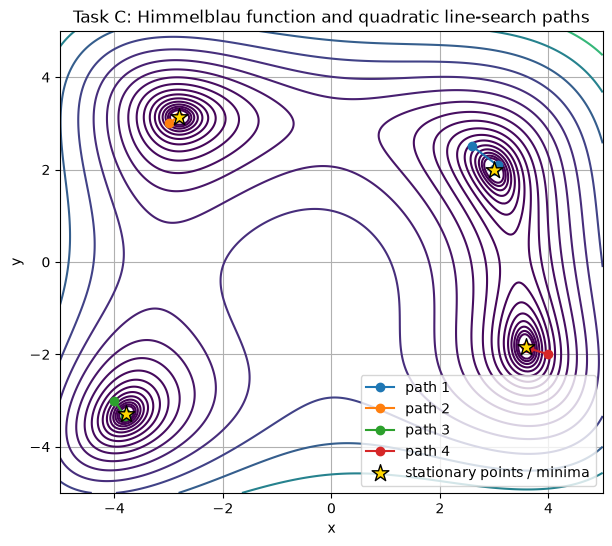

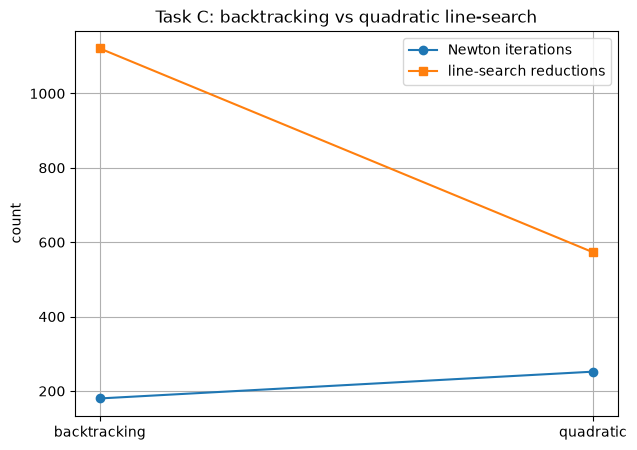

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- Rosenbrock plot ----------
rosen_path = np.loadtxt("root_C_rosenbrock_path.data")

x = np.linspace(-2.0, 2.0, 300)
y = np.linspace(-1.0, 3.0, 300)
X, Y = np.meshgrid(x, y)
Z = (1 - X)**2 + 100*(Y - X**2)**2

plt.figure(figsize=(7, 6))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 15))
plt.plot(rosen_path[:, 0], rosen_path[:, 1], marker="o", label="quadratic line-search path")
plt.scatter([1], [1],
            marker="*", s=160, color="gold",
            edgecolors="black", linewidths=1.0,
            label="stationary point / minimum", zorder=5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Task C: Rosenbrock function and quadratic line-search path")
plt.legend()
plt.grid(True)
plt.show()


# ---------- Himmelblau plot ----------
himmel_roots = np.loadtxt("root_C_himmelblau_roots.data")

x = np.linspace(-5.0, 5.0, 400)
y = np.linspace(-5.0, 5.0, 400)
X, Y = np.meshgrid(x, y)
Z = (X**2 + Y - 11)**2 + (X + Y**2 - 7)**2

plt.figure(figsize=(7, 6))
plt.contour(X, Y, Z, levels=np.logspace(0, 3, 18))

blocks = []
current = []

for line in Path("root_C_himmelblau_paths.data").read_text().splitlines():
    if line.strip():
        current.append([float(v) for v in line.split()])
    else:
        if current:
            blocks.append(np.array(current))
            current = []

if current:
    blocks.append(np.array(current))

for i, block in enumerate(blocks):
    plt.plot(block[:, 0], block[:, 1], marker="o", label=f"path {i+1}")

plt.scatter(himmel_roots[:, 0], himmel_roots[:, 1],
            marker="*", s=160, color="gold",
            edgecolors="black", linewidths=1.0,
            label="stationary points / minima", zorder=5)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Task C: Himmelblau function and quadratic line-search paths")
plt.legend()
plt.grid(True)
plt.show()


# ---------- Comparison plot ----------
summary = np.genfromtxt("root_C_summary.data", names=True, dtype=None, encoding=None)

methods = summary["method"]
iterations = summary["iterations"]
line_steps = summary["line_search_steps"]

plt.figure(figsize=(7, 5))
plt.plot(methods, iterations, marker="o", label="Newton iterations")
plt.plot(methods, line_steps, marker="s", label="line-search reductions")
plt.ylabel("count")
plt.title("Task C: backtracking vs quadratic line-search")
plt.grid(True)
plt.legend()
plt.show()

## Task C conclusion

In Task C, Newton's method was modified so that the Jacobian matrix is allocated once and updated in-place during the iterations. The simple backtracking line-search was also replaced by a quadratic interpolation line-search.

The method was tested on a one-dimensional equation, the Rosenbrock gradient, and the Himmelblau gradient. The one-dimensional test converged to the expected root, and the Rosenbrock test converged to the stationary point/minimum $(1,1)$. For Himmelblau's function, different starting points converged to the four known minima.

Compared with ordinary backtracking, the quadratic interpolation line-search used fewer line-search reductions in the Rosenbrock test. In this run it required more Newton iterations, but still converged correctly. This shows that the interpolation method changes the step-size selection and can reduce the amount of repeated backtracking.